In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats.qmc import Sobol

# Global parameters
S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0

# Use the exact powers of 2 for Sobol sequence balance properties
N_values = np.array([2**10, 2**12, 2**14, 2**16, 2**18, 2**20])

# Black-Scholes analytic price
def black_scholes_call(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

price_bs = black_scholes_call(S0, K, r, sigma, T)
print(f"Black-Scholes Analytic Price: {price_bs}")

Black-Scholes Analytic Price: 10.450583572185565


In [24]:
def std_vs_N(method_fn, N_values, price_true, runs=30, seed=123):
    """
    For each N in N_values, run method_fn 'runs' times and 
    return std deviation of (estimate - price_true).
    """
    rng = np.random.default_rng(seed)
    std_list = []
    
    for N in N_values:
        errors = []
        for _ in range(runs):
            # fresh RNG for each run
            local_rng = np.random.default_rng(rng.integers(0, 1_000_000_000))
            # if method accepts rng, pass it; otherwise call it without
            if 'rng' in method_fn.__code__.co_varnames:
                est = method_fn(N, S0, K, r, sigma, T, rng=local_rng)
            else:
                est = method_fn(N, S0, K, r, sigma, T)
            errors.append(est - price_true)
        std_list.append(np.style.std(errors, ddof=1) if hasattr(np, 'style') else np.std(errors, ddof=1))
    return np.array(std_list)

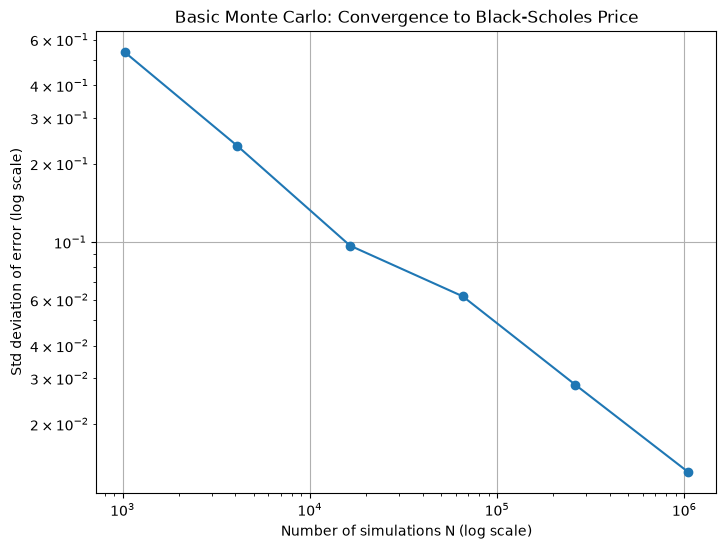

In [25]:
def mc_call_basic(N, S0, K, r, sigma, T, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    Z = rng.standard_normal(N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    X = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    return np.mean(X)

# Experiment for basic MC
std_basic = std_vs_N(mc_call_basic, N_values, price_bs, runs=30)

plt.figure(figsize=(8, 6))
plt.plot(N_values, std_basic, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of simulations N (log scale)')
plt.ylabel('Std deviation of error (log scale)')
plt.title('Basic Monte Carlo: Convergence to Black-Scholes Price')
plt.grid(True)
plt.show()


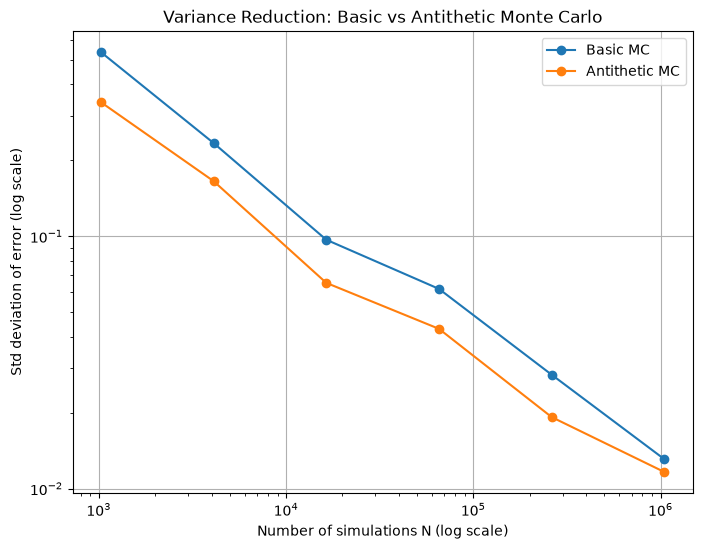

In [26]:
def mc_call_antithetic(N, S0, K, r, sigma, T, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    Z = rng.standard_normal(N // 2)
    
    ST_plus = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    ST_minus = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * (-Z))
    
    X_plus = np.exp(-r * T) * np.maximum(ST_plus - K, 0.0)
    X_minus = np.exp(-r * T) * np.maximum(ST_minus - K, 0.0)
    
    X_pair = 0.5 * (X_plus + X_minus)
    return np.mean(X_pair)

# Experiment: basic vs antithetic
std_basic = std_vs_N(mc_call_basic, N_values, price_bs, runs=30)
std_anti = std_vs_N(mc_call_antithetic, N_values, price_bs, runs=30)

plt.figure(figsize=(8, 6))
plt.plot(N_values, std_basic, marker='o', label='Basic MC')
plt.plot(N_values, std_anti, marker='o', label='Antithetic MC')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of simulations N (log scale)')
plt.ylabel('Std deviation of error (log scale)')
plt.title('Variance Reduction: Basic vs Antithetic Monte Carlo')
plt.grid(True)
plt.legend()
plt.show()

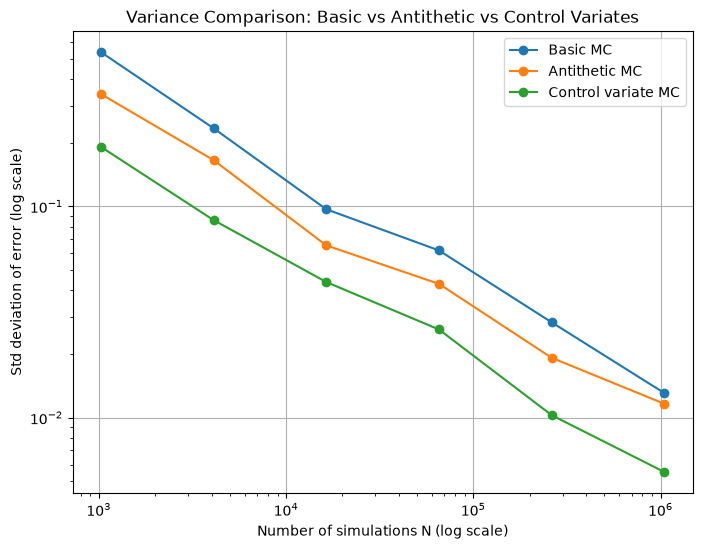

In [27]:
def mc_call_control_variate(N, S0, K, r, sigma, T, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    Z = rng.standard_normal(N)
    
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    X = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    
    Y = ST                  # control variate
    EY = S0 * np.exp(r * T) # E[S_T] under risk-neutral measure
    
    cov_xy = np.cov(X, Y, ddof=1)[0, 1]
    var_y = np.var(Y, ddof=1)
    beta = cov_xy / var_y
    
    C_cv = X - beta * (Y - EY)
    return np.mean(C_cv)

# Experiment: Basic vs Antithetic vs Control variate
std_basic = std_vs_N(mc_call_basic, N_values, price_bs, runs=30)
std_anti = std_vs_N(mc_call_antithetic, N_values, price_bs, runs=30)
std_cv = std_vs_N(mc_call_control_variate, N_values, price_bs, runs=30)

plt.figure(figsize=(8, 6))
plt.plot(N_values, std_basic, marker='o', label='Basic MC')
plt.plot(N_values, std_anti, marker='o', label='Antithetic MC')
plt.plot(N_values, std_cv, marker='o', label='Control variate MC')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of simulations N (log scale)')
plt.ylabel('Std deviation of error (log scale)')
plt.title('Variance Comparison: Basic vs Antithetic vs Control Variates')
plt.grid(True)
plt.legend()
plt.show()


N=   1024: Basic=0.53721, Anti=0.34015, CV=0.19133, QMC=0.01212
N=   4096: Basic=0.23424, Anti=0.16547, CV=0.08612, QMC=0.00341
N=  16384: Basic=0.09689, Anti=0.06536, CV=0.04384, QMC=0.00070
N=  65536: Basic=0.06186, Anti=0.04296, CV=0.02614, QMC=0.00013
N= 262144: Basic=0.02825, Anti=0.01919, CV=0.01027, QMC=0.00003
N=1048576: Basic=0.01307, Anti=0.01163, CV=0.00553, QMC=0.00001


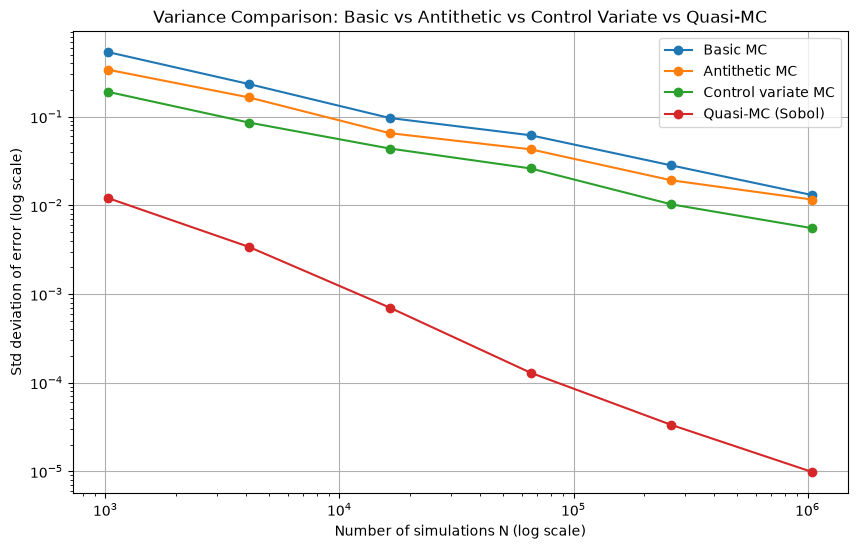

In [28]:
def quasi_Z(N, d=1, scramble=True):
    sampler = Sobol(d=d, scramble=scramble)
    u = sampler.random(n=N) # N points in (0,1)
    Z = norm.ppf(u)         # map to N(0,1)
    return Z.flatten()

def mc_call_quasi(N, S0, K, r, sigma, T):
    Z = quasi_Z(N, d=1)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    X = np.exp(-r * T) * np.maximum(ST - K, 0.0)
    return np.mean(X)

# Experiment: all four methods
std_basic = std_vs_N(mc_call_basic, N_values, price_bs, runs=30)
std_anti = std_vs_N(mc_call_antithetic, N_values, price_bs, runs=30)
std_cv = std_vs_N(mc_call_control_variate, N_values, price_bs, runs=30)
std_qmc = std_vs_N(mc_call_quasi, N_values, price_bs, runs=30)

for N, sb, sa, sc, sq in zip(N_values, std_basic, std_anti, std_cv, std_qmc):
    print(f"N={N:7d}: Basic={sb:.5f}, Anti={sa:.5f}, CV={sc:.5f}, QMC={sq:.5f}")

plt.figure(figsize=(10, 6))
plt.plot(N_values, std_basic, marker='o', label='Basic MC')
plt.plot(N_values, std_anti, marker='o', label='Antithetic MC')
plt.plot(N_values, std_cv, marker='o', label='Control variate MC')
plt.plot(N_values, std_qmc, marker='o', label='Quasi-MC (Sobol)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of simulations N (log scale)')
plt.ylabel('Std deviation of error (log scale)')
plt.title('Variance Comparison: Basic vs Antithetic vs Control Variate vs Quasi-MC')
plt.grid(True)
plt.legend()
plt.show()